# Calculates UHI 

## Load libraries

Here we load the required libraries to execute the notebook. Note that specific code from dedicated scripts (`utils.py`, `urban_areas.py`, ...) is also loaded here.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!echo $CONDA_DEFAULT_ENV

jsc


In [3]:
import os

import pandas as pd
import numpy as np
from urclimask.GHCNd_stations import get_valid_timeseries, inside_city
from urclimask.UHI_analysis import UrbanIsland
from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import load_ucdb_city, traverseDir

In [4]:
import matplotlib.pyplot as plt

In [5]:
from tools import (
    check_equal_period,
    fix_360_longitudes,
    open_datasets,
    standardize_unit,
)

In [6]:
import xarray as xr

In [7]:
import sys

In [8]:
save_results_path = os.path.abspath(
    os.path.join(os.getcwd(), "..", "intermediate-results")
)
save_figure_path = os.path.abspath(os.path.join(os.getcwd(), "..", "plots"))
save_figure_dataset = os.path.abspath(os.path.join(os.getcwd(), "..", "datasets"))

# CORDEX-EUR-CMIP6

In [9]:
city = "Birmingham"
country = "United Kingdom"

domain = "EUR-11"
model = "REMO"
scenario = "evaluation"

urban_var = "sfturf"

urban_th = 40
urban_sur_th = 5
orog_diff = 100
sftlf_th = 70
ratio_r2u = 2
min_city_size = 30
lon_lim = 1
lat_lim = 1
height_station = 100

variable = "sfcWind"
period_star = "1991"
period_stop = "2020"
period = slice(period_star, period_stop)

domain_resolution = int(domain.split("-")[1])

In [59]:
### Load city shapefile
root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_city = load_ucdb_city(root_aux_data, city, country)

# ---------------------------------------------------------------
# GET LON/LAT FROM THE CITY GEOMETRY
# ---------------------------------------------------------------
import geopandas as gpd

# Ensure CRS is WGS84 (EPSG:4326)
if ucdb_city.crs is None or ucdb_city.crs.to_epsg() != 4326:
    ucdb_city = ucdb_city.to_crs(epsg=4326)

# Compute centroid (in case geometry is a polygon)
centroid = ucdb_city.geometry.centroid.iloc[0]

lon_city = centroid.x
lat_city = centroid.y

print(f"{city}, {country}: lon: {lon_city:.4f}, lat: {lat_city:.4f}")


Stuttgart, Germany: lon: 9.2108, lat: 48.7926


/tmp/ipykernel_3066330/2874216552.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = ucdb_city.geometry.centroid.iloc[0]


# CMIP6

In [60]:
mip_era = "CMIP6"
driving_source_id = "ERA5"
frequency = "day"#1hr

In [61]:
dsets = open_datasets(
    [variable],
    frequency=frequency,
    driving_source_id=driving_source_id,
    mask=True,
    add_missing_bounds=False, 
    source_id =['RACMO23E', 'ICON-CLM-202407-1-1', 'CCLM6-0-1-URB', 'HCLIM43-ALADIN', 'ROAM-NBS', 'REMO2020-2-2-iMOVE-LUC', 'REMO2020-2-2-MR2', 'REMO2020-2-2-TEB', 'REMO2020-2-2', 'REMO2020-2-2-iMOVE', 'WRF451Q', 'CNRM-ALADIN64E1', 'RegCM5-0', 'ALARO1-SFX']
    
)

Opening catalog from https://raw.githubusercontent.com/euro-cordex/joint-evaluation/refs/heads/main/CORDEX-CMIP6.json
Found 12 datasets for variables ['hurs']: ['RACMO23E', 'ICON-CLM-202407-1-1', 'CCLM6-0-1-URB', 'HCLIM43-ALADIN', 'ROAM-NBS', 'REMO2020-2-2-iMOVE-LUC', 'REMO2020-2-2-TEB', 'REMO2020-2-2-iMOVE', 'WRF451Q', 'CNRM-ALADIN64E1', 'RegCM5-0', 'ALARO1-SFX']

--> The keys in the returned dictionary of datasets are constructed as follows:
	'project_id.domain_id.institution_id.driving_source_id.driving_experiment_id.driving_variant_label.source_id.version_realization.frequency.version'


decoding dataset CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630
Warning for CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630: Variable(s) referenced in cell_measures not in variables: ['areacella']
Found 27 datasets
decoding dataset CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.fx.v20241205
Found 27 datasets
decoding dataset CORDEX-CMIP6.EUR-12.KNMI.ERA5.evaluation.r1i1p1f1.RACMO23E.v1-r1.fx.v20241216
Found 27 datasets
decoding dataset CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920
Warning for CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for C

/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/evaltools/fix.py:88: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.fx.v20250415.
  warnings.warn(message)
/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/evaltools/fix.py:88: UserWarning: Grid mapping has (18.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.AUTH.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r3.day.v20250630.
  warnings.warn(message)
/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/evaltools/fix.py:88: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.day.v20250415.
  warnings.warn(message)


merging CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.day.v20250201 with CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.fx.v20250201
merging CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.day.v20241205 with CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.fx.v20241205
merging CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE-LUC.v1-r1.day.v20250515 with CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE-LUC.v1-r1.fx.v20250515
merging CORDEX-CMIP6.EUR-12.IDL-FCUL.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.day.v20240630 with CORDEX-CMIP6.EUR-12.IDL-FCUL.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.fx.v20240630
fx dataset not found for CORDEX-CMIP6.EUR-12.AUTH.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r3.day.v20250630
merging CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.day.v20250515 with CORDEX-CMIP6.EUR-12.G

In [62]:
# delete simulatios with not urban static variable
to_delete = [dset for dset, ds in dsets.items() if urban_var not in ds.variables]

for dset in to_delete:
    del dsets[dset]

In [63]:
for dset in dsets.keys():
    dsets[dset] = dsets[dset].sel(time=period)

In [64]:
for dset in dsets.keys():
    if not check_equal_period(dsets[dset], period):
        print(f"Temporal coverage of {dset} does not match with {period}")

Temporal coverage of CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.day.v20250415 does not match with slice('1991', '2020', None)


In [65]:
for dset in dsets.keys():
    dsets[dset] = standardize_unit(dsets[dset], variable)

## Define urban areas and vicinity

## Paris 

In [66]:
if city == 'Paris':
    var_map = {
        'tas': 'TAVG',
        'tasmin': 'TMIN',
        'tasmax': 'TMAX',
        'pr': 'PRCP',
        'sfcWind': 'SNWD',
        'hurs': 'HU'
    }
else:
    var_map = {
        'tasmin': 'tasmin',
        'tasmax': 'tasmax',
        'pr': 'pr',
        'sfcWind': 'sfcWind',
        'hurs': 'hurs'
    }

In [67]:
if city == 'Paris':
    
    root = "/mnt/CORDEX_CMIP6_tmp/aux_data/PARIS_surface_weather_data/"
    files_obs_paris = list(traverseDir(root, '.csv'))
    files_obs_paris = [f for f in files_obs_paris if "198001" in f]
    
    df_all = []
    for file in files_obs_paris:
    
        if variable == 'pr':
            var_paris = 'RR1'
        elif variable in ['tas', 'tasmax', 'tasmin']:
            var_paris = 'T'
        elif variable == 'sfcWind':
            var_paris = 'FF'
        elif variable == 'hurs':
            var_paris = 'U'
    
        df = pd.read_csv(
            file,
            sep=";",
            decimal=",",
            na_values=["", " "]
        )
    
        df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d%H")
        df.set_index("DATE", inplace=True)
        df = df.sort_index()
    
        # Extrae código de estación
        station_code = df["POSTE"].iloc[0]
        station_name = file.split('/')[-1].split('_')[-1].split('.csv')[0]
    
        if variable == 'tasmax':
            df_daily = df[[var_paris]].resample("D").max()
        elif variable == 'tasmin':
            df_daily = df[[var_paris]].resample("D").min()
        else:
            df_daily = df[[var_paris]]
    
        df_var = pd.DataFrame(index=df_daily.index)
        df_var[var_map.get(variable, None)] = df_daily[var_paris]
        df_var["NAME"] = station_name
        df_var["code"] = station_code
    
        df_all.append(df_var)
    
    df_obs = pd.concat(df_all)


### Load static variables
Load static variables, such as urban fraction (sfturf), terrain elevation (orography) or land-sea fraction (sftlf).

In [68]:
# all values equal to 0
# del dsets['CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.mon.v20250520']

In [69]:
keys = [k for k in dsets.keys()]

In [70]:
keys

['CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.day.v20250201',
 'CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.day.v20241205',
 'CORDEX-CMIP6.EUR-12.IDL-FCUL.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.day.v20240630',
 'CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.day.v20250415',
 'CORDEX-CMIP6.EUR-12.DWD-BSH.ERA5.evaluation.r1i1p1f1.ROAM-NBS.v1-r1.day.v20240920',
 'CORDEX-CMIP6.EUR-12.KNMI.ERA5.evaluation.r1i1p1f1.RACMO23E.v1-r1.day.v20241216',
 'CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.day.v20240920',
 'CORDEX-CMIP6.EUR-12.RMIB-UGent.ERA5.evaluation.r1i1p1f1.ALARO1-SFX.v1-r1.day.v20241009',
 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-TEB.v1-r1.day.v20251028']

In [71]:
from geopy.distance import geodesic
from math import sqrt

def compute_distance(row):
    dlat = abs(lat_city - row["lat"])
    dlon = abs(lon_city - row["lon"])
    return sqrt(dlat**2 + dlon**2)


In [72]:
from math import radians, cos, sin, asin, sqrt
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

## Calculates and saves UHI annual cycle for each model

CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.day.v20250201
CCLM6-0-1-URB_v1-r1: min() arg is an empty sequence — skipping.
CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.day.v20241205
HCLIM43-ALADIN_v1-r1: min_dist = 115.73 km
CORDEX-CMIP6.EUR-12.IDL-FCUL.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.day.v20240630
WRF451Q_v1-r1: min_dist = 8.13 km
CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.day.v20250415
RegCM5-0_v1-r1: min_dist = 10.42 km


/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urclimask/urclimask/urban_areas.py:153: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned_mask = morphology.remove_small_objects(labeled_mask, min_size=self.min_city_size)


CORDEX-CMIP6.EUR-12.DWD-BSH.ERA5.evaluation.r1i1p1f1.ROAM-NBS.v1-r1.day.v20240920
ROAM-NBS_v1-r1: min() arg is an empty sequence — skipping.
CORDEX-CMIP6.EUR-12.KNMI.ERA5.evaluation.r1i1p1f1.RACMO23E.v1-r1.day.v20241216
RACMO23E_v1-r1: min_dist = 8.12 km
CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.day.v20240920
ICON-CLM-202407-1-1_v1-r1: min() arg is an empty sequence — skipping.
CORDEX-CMIP6.EUR-12.RMIB-UGent.ERA5.evaluation.r1i1p1f1.ALARO1-SFX.v1-r1.day.v20241009
ALARO1-SFX_v1-r1: min() arg is an empty sequence — skipping.
CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-TEB.v1-r1.day.v20251028
REMO2020-2-2-TEB_v1-r1: min_dist = 8.12 km


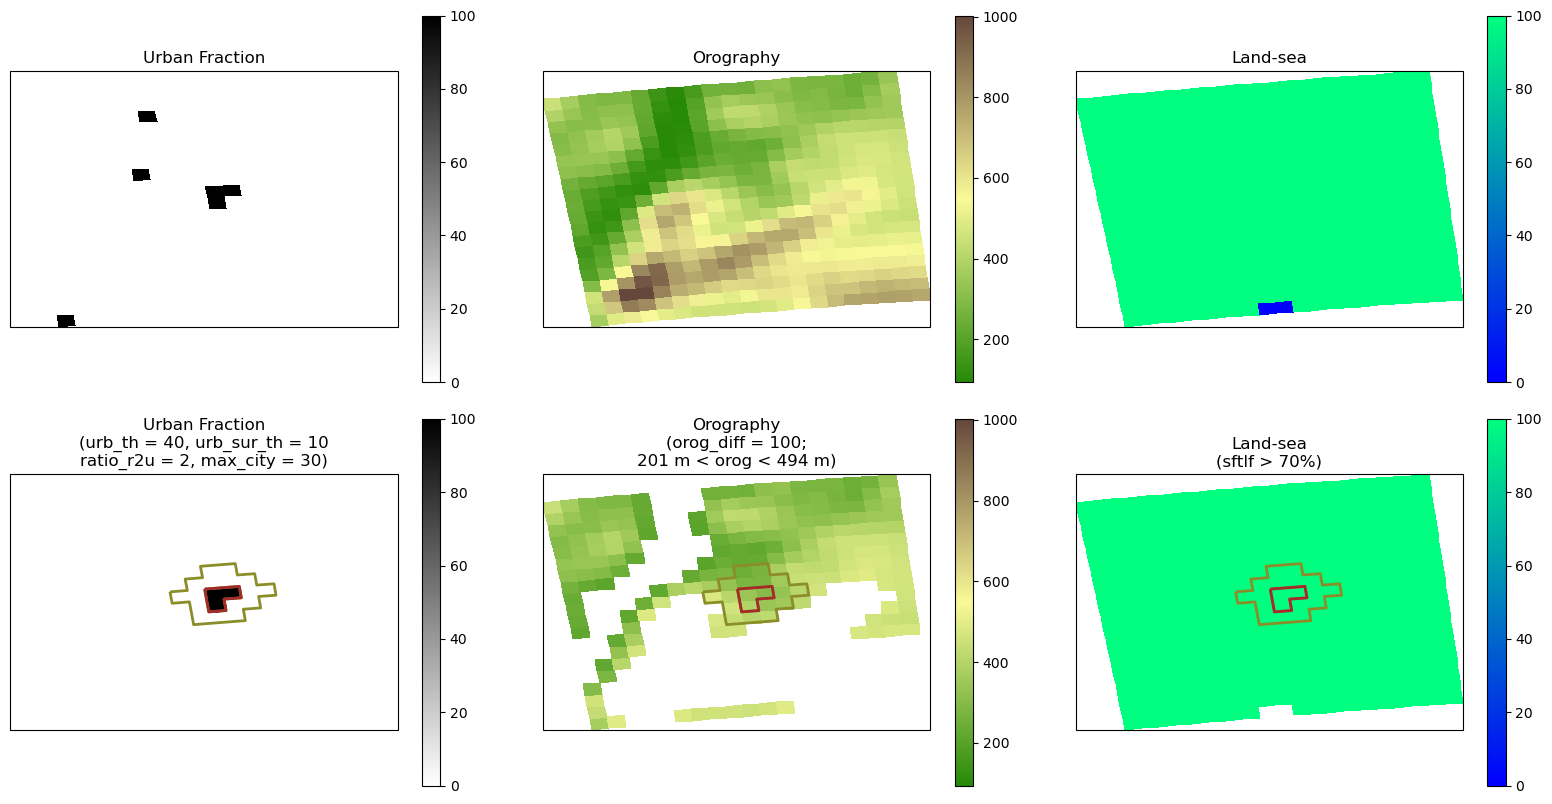

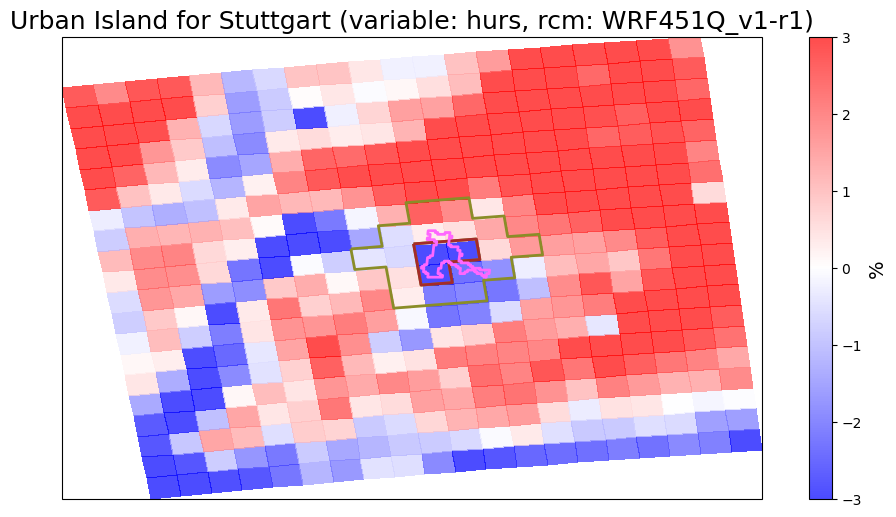

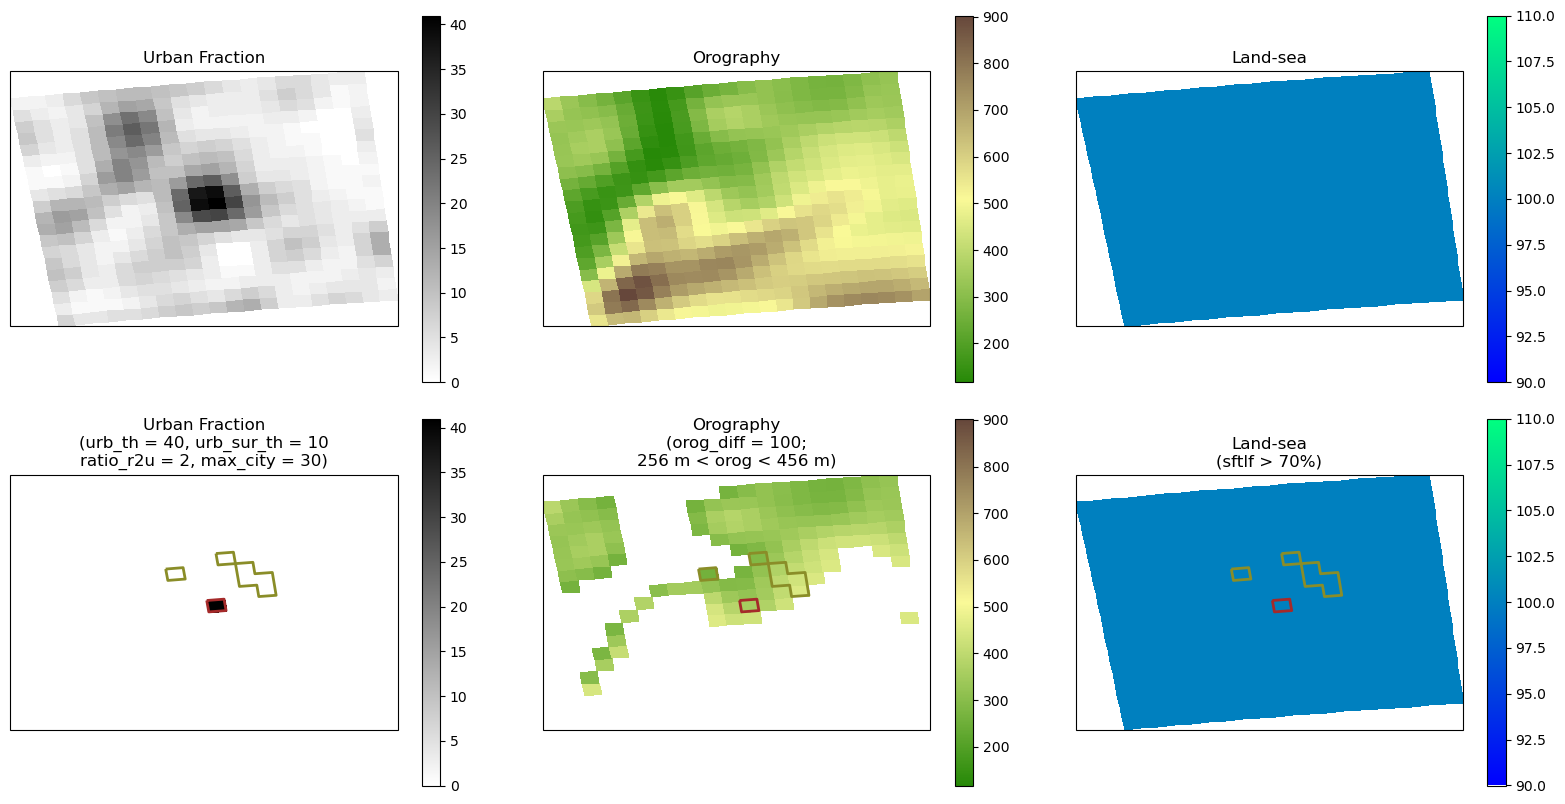

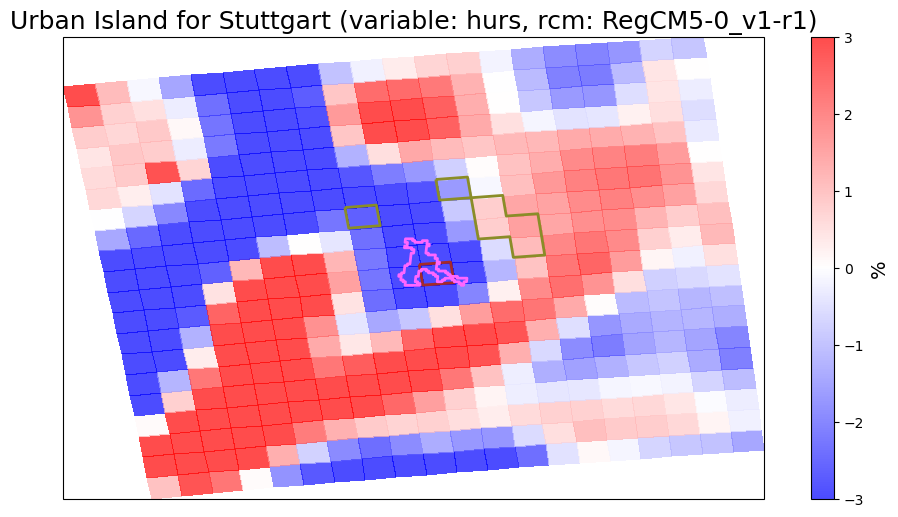

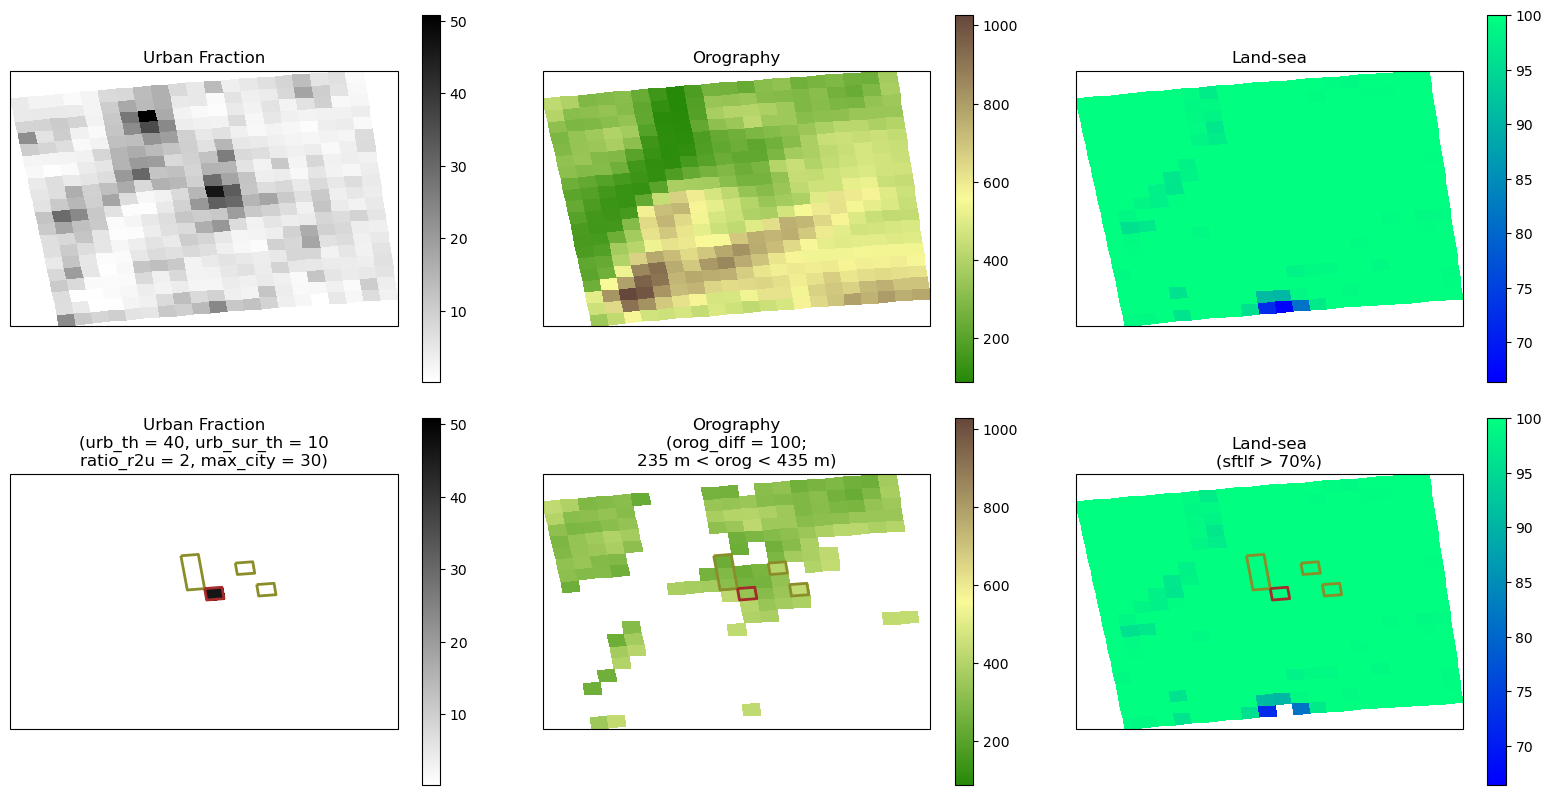

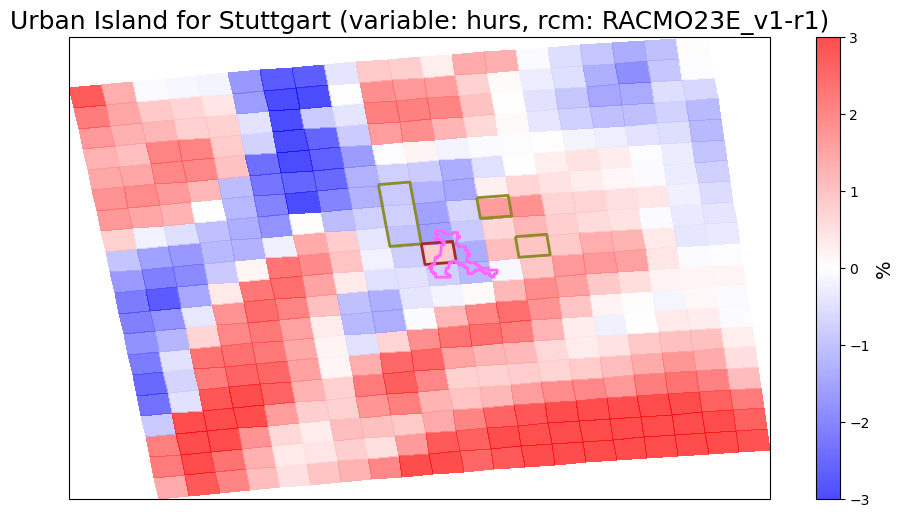

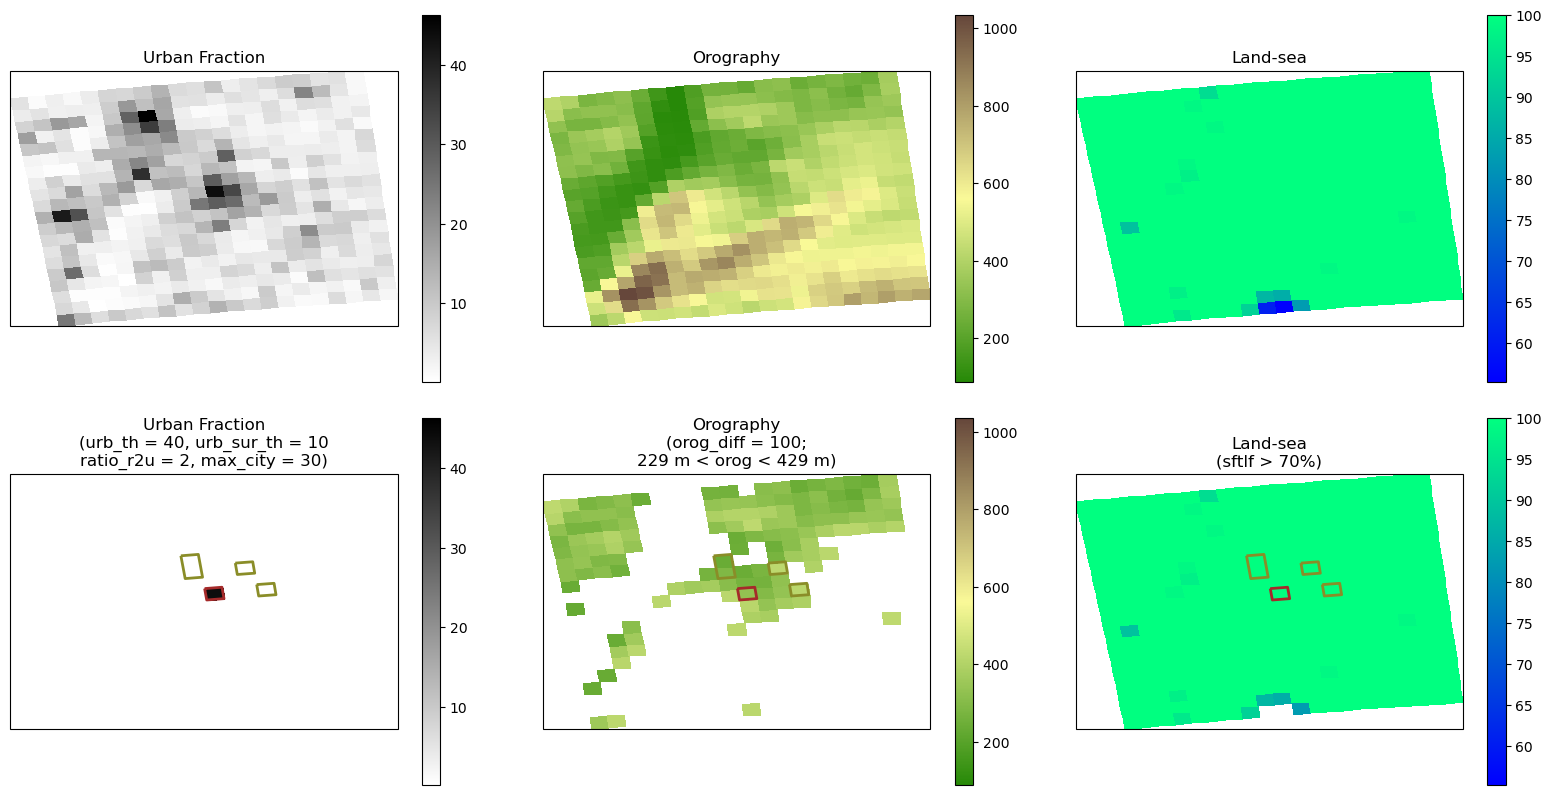

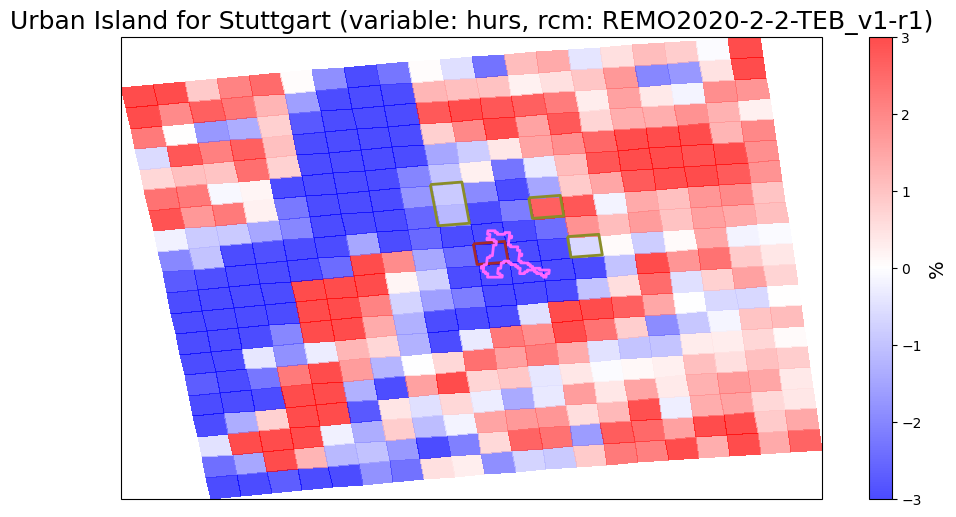

In [73]:
# ==============================================================
# Loop through all datasets and compute UHI metrics per model
# ==============================================================

rcm_names = []

for dset, ds in dsets.items():
    print(dset)

    # --- Fix longitudes to 0–360 if needed ---
    ds = fix_360_longitudes(ds, lonname="lon")

    # --- Load required variables ---
    ds_sfturf = ds[[urban_var]].compute()
    ds_orog = ds[["orog"]].compute()
    ds_sftlf = ds[["sftlf"]].compute()

    # --- Identify RCM name from metadata ---
    try:
        rcm_name = ds.attrs["model_id"] + "_" + ds.attrs["rcm_version_id"]
    except Exception:
        rcm_name = ds.attrs["source_id"] + "_" + ds.attrs["version_realization"]

    # --- Initialize UrbanVicinity class ---
    URBAN = UrbanVicinity(
        urban_sur_th=urban_sur_th,
        orog_diff=orog_diff,
        sftlf_th=sftlf_th,
        ratio_r2u=ratio_r2u,
        min_city_size=min_city_size,
        lon_city=lon_city,
        lat_city=lat_city,
        lon_lim=lon_lim,
        lat_lim=lat_lim,
        model=model,
        domain=domain,
        urban_th=urban_th,
        urban_var=urban_var,
    )

    # --- Crop model domain around the target city ---
    ds_sfturf = URBAN.crop_area_city(ds=ds_sfturf, res=domain_resolution)
    ds_orog = URBAN.crop_area_city(ds=ds_orog, res=domain_resolution)
    ds_sftlf = URBAN.crop_area_city(ds=ds_sftlf, res=domain_resolution)

    # --- Define masks for urban, surrounding, orographic and land fraction areas ---
    try:
        sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
            ds_sfturf=ds_sfturf,
            ds_orog=ds_orog,
            ds_sftlf=ds_sftlf,
        )
    except ValueError as e:
        print(f"{rcm_name}: {e} — skipping.")
        continue

    # --- Select urban vicinity mask ---
    urmask = URBAN.select_urban_vicinity(
        sfturf_mask=sfturf_mask,
        orog_mask=orog_mask,
        sftlf_mask=sftlf_mask,
        sfturf_sur_mask=sfturf_sur_mask,
    )

    # --- Check minimum distance between detected urban cells and city center ---
    urmask_values = urmask["urmask"].values
    if np.any(urmask_values == 1):
        lat_urban = urmask.lat.values[urmask_values == 1]
        lon_urban = urmask.lon.values[urmask_values == 1]

        min_dist = min(
            haversine(lat_city, lon_city, la, lo)
            for la, lo in zip(lat_urban, lon_urban)
        )
        print(f"{rcm_name}: min_dist = {min_dist:.2f} km")

        # Skip model if no urban area is found within 25 km of the city
        if min_dist >= 25:
            continue

    # --- Save urban vicinity mask if not already saved ---
    output_urmask_nc_path = f"{save_figure_dataset}/urmask/CMIP6_{city}_urmask_{rcm_name}.nc"
    if not os.path.exists(output_urmask_nc_path):
        urmask.to_netcdf(output_urmask_nc_path)

    # --- Plot static variables and save the figure ---
    fig = URBAN.plot_static_variables(
        ds_sfturf=ds_sfturf,
        ds_orog=ds_orog,
        ds_sftlf=ds_sftlf,
        sfturf_mask=sfturf_mask,
        orog_mask=orog_mask,
        sftlf_mask=sftlf_mask,
        urban_areas=urmask,
    )


    # ==============================================================
    #                 Urban Heat Island computation
    # ==============================================================

    ds_RCM = ds[[variable]]
    ds_RCM = URBAN.crop_area_city(ds=ds_RCM, res=domain_resolution)
    rcm_names.append(rcm_name)

    # --- Handle observational data ---
    df_obs = pd.DataFrame()
    time_series_obs = pd.DataFrame()
   
    # --- Define anomaly type and color limits ---
    if variable in ["sfcWind"]:
        anomaly = "abs"
        vmax = 25
        vmin = -25
    elif variable in ["tasmax", "tasmin", 'tas', 'hurs']:
        anomaly = "abs"
        vmax = 3
        vmin = -1.5


    # --- Initialize UrbanIsland class ---
    UHI = UrbanIsland(
        ds=ds_RCM[variable],
        urban_vicinity=urmask,
        rcm=rcm_name,
        anomaly=anomaly
    )

    # --- Plot UHI map ---
    fig = UHI.plot_UI_map(city_name=city, ucdb_city=ucdb_city, vmax=vmax)

    # --- Compute annual cycle climatology ---
    UHI.compute_annual_cycle()

    # --- Save output NetCDF and CSV if available ---
    output_nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_{period.start}-{period.stop}.nc"
    output_obs_nc_path = f"{save_figure_dataset}/Annual_cycle/observations/CMIP6_{city}_Annual_cycle_{variable}_OBS_{period.start}-{period.stop}.csv"

    # Save model annual cycle only if file does not already exist
    if not os.path.exists(output_nc_path):
        UHI.ds_annual_cycle.to_netcdf(output_nc_path)

